# Deep Learning Modelleri - Route 502

Bu notebook, baseline modellerin uzerine LSTM ve GRU modelleri ekler.

**Yaklasim:** Bir trip icindeki onceki duraklarin seyahat surelerini sliding window ile
LSTM'e vererek sonraki duragin suresini tahmin ediyoruz.

**Modeller:**
1. LSTM (128 unit, makale ile ayni mimari)
2. GRU (128 unit, LSTM alternatifi)

**Referans:** Kaya & Kalay, IEEE Access 2025 — MAE: 2.97 dk, MAPE: 14.79%, R²: 0.9272

In [1]:
import pandas as pd
import numpy as np
import os, sys, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
FEATURES_CSV = os.path.join(PROJECT_ROOT, 'collected_data', 'route_502_features_v2.csv')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'tables'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')

PyTorch: 2.11.0+cpu
Device: cpu


## 1. Veri Yukleme ve Hazirlik

In [2]:
df = pd.read_csv(FEATURES_CSV)
print(f'Dataset (v2): {len(df)} satir')

# --- v2 -> eski sema uyum katmani ---
df = df.rename(columns={
    'travel_time_min': 'travel_minutes',
    'scheduled_travel_min': 'scheduled_travel_minutes',
})
df['is_weekend'] = df['day_type'].astype(int)
df['deviation_minutes'] = df['travel_minutes'] - df['scheduled_travel_minutes']
_w_map = {0: 'clear', 1: 'cloudy', 2: 'rainy', 3: 'snowy'}
df['weather_category'] = df['weather_cat_enc'].map(_w_map).fillna('clear')
df['is_rainy'] = (df['weather_cat_enc'] == 2).astype(int)
_tb_map = {0: 'morning_peak', 1: 'off_peak', 2: 'evening_peak', 3: 'night'}
if pd.api.types.is_numeric_dtype(df['time_block']):
    df['time_block'] = df['time_block'].map(_tb_map).fillna('off_peak')

# Kategorik -> sayisal
le_tb = LabelEncoder()
df['time_block_enc'] = le_tb.fit_transform(df['time_block'])

le_wc = LabelEncoder()
df['weather_enc'] = le_wc.fit_transform(df['weather_category'].fillna('clear'))

# Model icin kullanilacak ozellikler
SEQUENCE_FEATURES = [
    'travel_minutes',              # Onceki duraklarin gercek suresi
    'scheduled_travel_minutes',    # GTFS planlanmis sure
    'deviation_minutes',           # Sapma
    'distance_m',                  # Mesafe
    'stop_progress',               # Hattaki konum
]

CONTEXT_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'time_block_enc',
    'temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc',
]

TARGET = 'travel_minutes'

print(f'Sequence features: {len(SEQUENCE_FEATURES)}')
print(f'Context features: {len(CONTEXT_FEATURES)}')

Dataset (v2): 138282 satir
Sequence features: 5
Context features: 9


## 2. Sliding Window Sequence Olusturma

Her trip icinde onceki N duragin bilgisini kullanarak sonraki duragin seyahat suresini tahmin ediyoruz.

```
Trip: [seg1, seg2, seg3, seg4, seg5, seg6]
Window=3:
  X = [seg1, seg2, seg3]  ->  y = seg4.travel_minutes
  X = [seg2, seg3, seg4]  ->  y = seg5.travel_minutes
  X = [seg3, seg4, seg5]  ->  y = seg6.travel_minutes
```

In [3]:
def create_sequences(df, window_size=3):
    """
    Trip bazinda sliding window olustur.
    
    Returns:
        X_seq: (n_samples, window_size, n_seq_features) - LSTM girdisi
        X_ctx: (n_samples, n_ctx_features) - Context girdisi
        y: (n_samples,) - Hedef
    """
    X_seq_list = []
    X_ctx_list = []
    y_list = []
    
    # Trip gruplari: ayni otobus, ayni yon, ayni baslangic zamani
    trip_groups = df.groupby(['bus_id', 'yon', 'trip_start_time'])
    
    for _, trip in trip_groups:
        trip = trip.sort_values('from_stop_seq', ascending=False)  # Buyukten kucuge (gidis yonu)
        
        if len(trip) < window_size + 1:
            continue
        
        seq_vals = trip[SEQUENCE_FEATURES].values
        ctx_vals = trip[CONTEXT_FEATURES].values
        target_vals = trip[TARGET].values
        
        for i in range(window_size, len(trip)):
            X_seq_list.append(seq_vals[i - window_size:i])
            X_ctx_list.append(ctx_vals[i])  # Hedef segmentin context'i
            y_list.append(target_vals[i])
    
    if not X_seq_list:
        return np.array([]), np.array([]), np.array([])
    
    return np.array(X_seq_list), np.array(X_ctx_list), np.array(y_list)


# Farkli window boyutlarini dene
for ws in [2, 3, 4, 5]:
    X_s, X_c, y = create_sequences(df, window_size=ws)
    print(f'Window={ws}: {len(y)} ornek')

# Varsayilan window
WINDOW_SIZE = 3
if len(create_sequences(df, 3)[2]) < 5:
    WINDOW_SIZE = 2
    print(f'\nYeterli veri yok, window_size={WINDOW_SIZE} kullaniliyor')

X_seq, X_ctx, y = create_sequences(df, WINDOW_SIZE)
print(f'\nSecilen window_size={WINDOW_SIZE}')
print(f'X_seq shape: {X_seq.shape}  (ornekler, window, seq_features)')
print(f'X_ctx shape: {X_ctx.shape}  (ornekler, ctx_features)')
print(f'y shape: {y.shape}')

Window=2: 107977 ornek
Window=3: 97483 ornek
Window=4: 87121 ornek
Window=5: 76944 ornek

Secilen window_size=3
X_seq shape: (97483, 3, 5)  (ornekler, window, seq_features)
X_ctx shape: (97483, 9)  (ornekler, ctx_features)
y shape: (97483,)


## 3. Normalizasyon ve Train/Test Bolme

In [4]:
# Kronolojik bolme: ilk %80 train, son %20 test
split_idx = int(len(y) * 0.8)

X_seq_train, X_seq_test = X_seq[:split_idx], X_seq[split_idx:]
X_ctx_train, X_ctx_test = X_ctx[:split_idx], X_ctx[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Train: {len(y_train)}, Test: {len(y_test)}')

if len(y_test) < 3:
    print('\nUYARI: Test seti cok kucuk. Sonuclar gosterge niteliğindedir.')
    print('Daha fazla veri toplandiktan sonra yeniden calistirin.')

Train: 77986, Test: 19497


In [5]:
# Sequence features normalizasyonu
n_samples_train, n_steps, n_seq_feats = X_seq_train.shape
n_samples_test = X_seq_test.shape[0]

scaler_seq = MinMaxScaler()
X_seq_train_flat = X_seq_train.reshape(-1, n_seq_feats)
X_seq_test_flat = X_seq_test.reshape(-1, n_seq_feats)

scaler_seq.fit(X_seq_train_flat)
X_seq_train_norm = scaler_seq.transform(X_seq_train_flat).reshape(n_samples_train, n_steps, n_seq_feats)
X_seq_test_norm = scaler_seq.transform(X_seq_test_flat).reshape(n_samples_test, n_steps, n_seq_feats)

# Context features normalizasyonu
scaler_ctx = MinMaxScaler()
X_ctx_train_norm = scaler_ctx.fit_transform(X_ctx_train)
X_ctx_test_norm = scaler_ctx.transform(X_ctx_test)

print(f'Normalizasyon tamamlandi')
print(f'X_seq_train: {X_seq_train_norm.shape}')
print(f'X_ctx_train: {X_ctx_train_norm.shape}')

Normalizasyon tamamlandi
X_seq_train: (77986, 3, 5)
X_ctx_train: (77986, 9)


## 4. Model Mimarileri

Cift girdili mimari:
- **Sequence branch:** LSTM/GRU — onceki duraklarin temporal pattern'ini ogrenır
- **Context branch:** Dense — saat, hava, gun gibi statik bilgiyi isler
- **Merge:** iki dal birlestirilip final tahmin uretilir

In [6]:
class DualInputRNN(nn.Module):
    """
    Cift girdili LSTM/GRU modeli.
    Makale parametreleri: 128 unit, Dropout 0.2, Adam lr=0.001
    """
    def __init__(self, n_seq_feats, n_ctx_feats, rnn_type='LSTM', rnn_units=128, dropout=0.2):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(n_seq_feats, rnn_units, batch_first=True)
        else:
            self.rnn = nn.GRU(n_seq_feats, rnn_units, batch_first=True)
        self.rnn_drop = nn.Dropout(dropout)

        self.ctx_fc   = nn.Linear(n_ctx_feats, 32)
        self.ctx_relu = nn.ReLU()
        self.ctx_drop = nn.Dropout(dropout)

        self.fc1      = nn.Linear(rnn_units + 32, 64)
        self.fc1_relu = nn.ReLU()
        self.fc1_drop = nn.Dropout(dropout)
        self.out      = nn.Linear(64, 1)

    def forward(self, seq_x, ctx_x):
        rnn_out, _ = self.rnn(seq_x)
        rnn_out = self.rnn_drop(rnn_out[:, -1, :])   # son timestep

        ctx_out = self.ctx_drop(self.ctx_relu(self.ctx_fc(ctx_x)))

        merged = torch.cat([rnn_out, ctx_out], dim=1)
        out = self.fc1_drop(self.fc1_relu(self.fc1(merged)))
        return self.out(out).squeeze(1)


def build_model(rnn_type='LSTM'):
    model = DualInputRNN(n_seq_feats, len(CONTEXT_FEATURES), rnn_type=rnn_type).to(DEVICE)
    total = sum(p.numel() for p in model.parameters())
    print(f'{rnn_type} — toplam parametre: {total:,}')
    return model

sample_model = build_model('LSTM')

LSTM — toplam parametre: 79,809


## 5. Model Egitimi

In [7]:
def evaluate_model(y_true, y_pred, name):
    """Performans metriklerini hesapla."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {
        'model':      name,
        'MAE (dk)':   round(mae,  4),
        'RMSE (dk)':  round(rmse, 4),
        'MAPE (%)':   round(mape, 2),
        'R2':         round(r2,   4),
    }


def train_and_evaluate(rnn_type, epochs=30, batch_size=16, patience=15, lr=0.001):
    print(f'\n{"="*50}')
    print(f'{rnn_type} Modeli Egitiliyor...')
    print(f'{"="*50}')

    # Tensor'a donustur
    Xs_tr = torch.tensor(X_seq_train_norm, dtype=torch.float32)
    Xc_tr = torch.tensor(X_ctx_train_norm, dtype=torch.float32)
    y_tr  = torch.tensor(y_train,          dtype=torch.float32)

    Xs_te = torch.tensor(X_seq_test_norm,  dtype=torch.float32).to(DEVICE)
    Xc_te = torch.tensor(X_ctx_test_norm,  dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(Xs_tr, Xc_tr, y_tr)
    loader     = DataLoader(dataset, batch_size=min(batch_size, len(y_tr)), shuffle=True)

    model      = build_model(rnn_type)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.L1Loss()   # MAE

    # EarlyStopping
    best_val_loss   = float('inf')
    best_state      = None
    patience_count  = 0
    history         = {'train': [], 'val': []}

    val_Xs = torch.tensor(X_seq_test_norm, dtype=torch.float32).to(DEVICE)
    val_Xc = torch.tensor(X_ctx_test_norm, dtype=torch.float32).to(DEVICE)
    val_y  = torch.tensor(y_test,          dtype=torch.float32).to(DEVICE)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for Xsb, Xcb, yb in loader:
            Xsb, Xcb, yb = Xsb.to(DEVICE), Xcb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xsb, Xcb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        train_loss = epoch_loss / len(y_tr)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(val_Xs, val_Xc), val_y).item()

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'Early stopping: epoch {epoch+1}')
                break

    model.load_state_dict(best_state)

    # Tahmin
    model.eval()
    with torch.no_grad():
        y_pred = model(Xs_te, Xc_te).cpu().numpy()
    y_pred = np.clip(y_pred, 0, None)

    result = evaluate_model(y_test, y_pred, rnn_type)
    print(f'MAE:  {result["MAE (dk)"]:.4f} dk')
    print(f'RMSE: {result["RMSE (dk)"]:.4f} dk')
    print(f'MAPE: {result["MAPE (%)"]:.2f}%')
    print(f'R2:   {result["R2"]:.4f}')

    return model, history, result, y_pred

In [8]:
dl_results = []

if len(y_train) >= 3 and len(y_test) >= 1:
    # LSTM
    lstm_model, lstm_history, lstm_result, y_pred_lstm = train_and_evaluate('LSTM')
    dl_results.append(lstm_result)
    
    # GRU
    gru_model, gru_history, gru_result, y_pred_gru = train_and_evaluate('GRU')
    dl_results.append(gru_result)
else:
    print(f'Yetersiz veri: train={len(y_train)}, test={len(y_test)}')
    print('En az 3 train ve 1 test ornegi gerekli.')
    print('Daha fazla veri toplayip tekrar calistirin.')


LSTM Modeli Egitiliyor...
LSTM — toplam parametre: 79,809
MAE:  0.4138 dk
RMSE: 0.6914 dk
MAPE: 42.11%
R2:   0.0484

GRU Modeli Egitiliyor...
GRU — toplam parametre: 62,529
MAE:  0.4140 dk
RMSE: 0.6887 dk
MAPE: 41.89%
R2:   0.0558


## 6. Baseline ile Karsilastirma

In [9]:
if dl_results:
    # Baseline sonuclarini yukle
    baseline_csv = os.path.join(RESULTS_DIR, 'tables', 'baseline_results.csv')
    if os.path.exists(baseline_csv):
        baseline_df = pd.read_csv(baseline_csv)
        all_results = pd.concat([baseline_df, pd.DataFrame(dl_results)], ignore_index=True)
    else:
        all_results = pd.DataFrame(dl_results)
    
    all_results = all_results.sort_values('MAE (dk)')
    
    print('='*70)
    print('TUM MODELLER - KARSILASTIRMA')
    print('='*70)
    print(all_results.to_string(index=False))
    print('='*70)
    print(f'\nMakale: MAE=2.97 dk, MAPE=14.79%, R2=0.9272')
    
    if len(y_test) < 20:
        print(f'\n** Test seti {len(y_test)} ornek — gosterge niteliğinde **')
    
    # DL sonuclarini kaydet
    dl_csv = os.path.join(RESULTS_DIR, 'tables', 'dl_results.csv')
    pd.DataFrame(dl_results).to_csv(dl_csv, index=False)
    
    # Tum karsilastirmayi kaydet
    all_csv = os.path.join(RESULTS_DIR, 'tables', 'all_model_results.csv')
    all_results.to_csv(all_csv, index=False)
    print(f'\nKaydedildi: {all_csv}')

TUM MODELLER - KARSILASTIRMA
                 model  MAE (dk)  RMSE (dk)  MAPE (%)      R2
                  LSTM    0.4138     0.6914     42.11  0.0484
                   GRU    0.4140     0.6887     41.89  0.0558
         Random Forest    0.4695     0.8731     50.22  0.3325
               XGBoost    0.4784     0.8819     52.15  0.3191
    Historical Average    0.5662     0.9922     62.50  0.1379
     Linear Regression    0.5933     1.0597     64.33  0.0167
Naive (GTFS Scheduled)    0.6125     1.0935     64.99 -0.0470

Makale: MAE=2.97 dk, MAPE=14.79%, R2=0.9272

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\tables\all_model_results.csv


## 7. Gorsellestirmeler

In [10]:
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print('matplotlib bulunamadi')

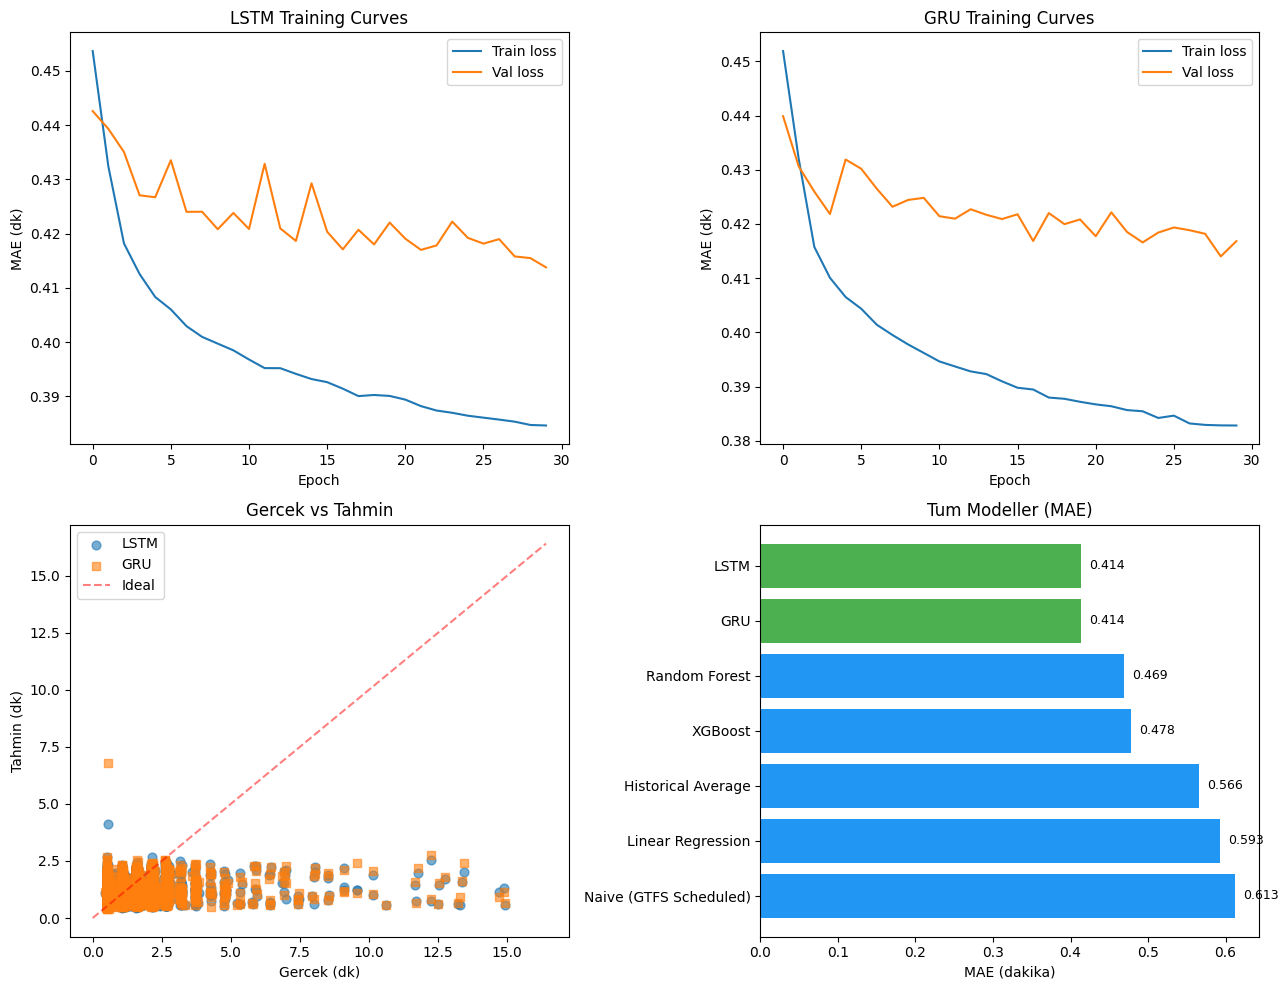

Gorsel kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\figures\dl_comparison.png


In [11]:
if HAS_PLT and dl_results:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # 1. Training curves - LSTM
    axes[0, 0].plot(lstm_history['train'], label='Train loss')
    axes[0, 0].plot(lstm_history['val'],   label='Val loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MAE (dk)')
    axes[0, 0].set_title('LSTM Training Curves')
    axes[0, 0].legend()

    # 2. Training curves - GRU
    axes[0, 1].plot(gru_history['train'], label='Train loss')
    axes[0, 1].plot(gru_history['val'],   label='Val loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MAE (dk)')
    axes[0, 1].set_title('GRU Training Curves')
    axes[0, 1].legend()

    # 3. Gercek vs Tahmin scatter
    axes[1, 0].scatter(y_test, y_pred_lstm, alpha=0.6, s=40, label='LSTM', marker='o')
    axes[1, 0].scatter(y_test, y_pred_gru,  alpha=0.6, s=40, label='GRU',  marker='s')
    lim = max(y_test.max(), y_pred_lstm.max(), y_pred_gru.max()) * 1.1
    axes[1, 0].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='Ideal')
    axes[1, 0].set_xlabel('Gercek (dk)')
    axes[1, 0].set_ylabel('Tahmin (dk)')
    axes[1, 0].set_title('Gercek vs Tahmin')
    axes[1, 0].legend()

    # 4. Model karsilastirmasi bar chart
    if len(all_results) > 0:
        colors = ['#4CAF50' if 'LSTM' in m or 'GRU' in m else '#2196F3'
                  for m in all_results['model']]
        axes[1, 1].barh(all_results['model'], all_results['MAE (dk)'], color=colors)
        axes[1, 1].set_xlabel('MAE (dakika)')
        axes[1, 1].set_title('Tum Modeller (MAE)')
        axes[1, 1].invert_yaxis()
        for i, v in enumerate(all_results['MAE (dk)']):
            axes[1, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, 'figures', 'dl_comparison.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gorsel kaydedildi: {fig_path}')

## 8. Modelleri Kaydet

In [12]:
if dl_results:
    # LSTM modeli
    lstm_path = os.path.join(MODELS_DIR, 'lstm_model.pt')
    torch.save(lstm_model.state_dict(), lstm_path)
    print(f'LSTM modeli kaydedildi: {lstm_path}')

    # GRU modeli
    gru_path = os.path.join(MODELS_DIR, 'gru_model.pt')
    torch.save(gru_model.state_dict(), gru_path)
    print(f'GRU modeli kaydedildi: {gru_path}')

    # Scaler ve config kaydet (inference icin)
    import pickle
    scaler_path = os.path.join(MODELS_DIR, 'scalers.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump({
            'scaler_seq':        scaler_seq,
            'scaler_ctx':        scaler_ctx,
            'le_time_block':     le_tb,
            'le_weather':        le_wc,
            'window_size':       WINDOW_SIZE,
            'sequence_features': SEQUENCE_FEATURES,
            'context_features':  CONTEXT_FEATURES,
            'n_seq_feats':       n_seq_feats,
        }, f)
    print(f'Scaler ve config kaydedildi: {scaler_path}')

LSTM modeli kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\lstm_model.pt
GRU modeli kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\gru_model.pt
Scaler ve config kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\scalers.pkl


## Sonuc

| Cikti | Dosya |
|-------|-------|
| LSTM modeli | `models/lstm_model.keras` |
| GRU modeli | `models/gru_model.keras` |
| Scalers | `models/scalers.pkl` |
| DL sonuclari | `results/tables/dl_results.csv` |
| Tum sonuclar | `results/tables/all_model_results.csv` |
| Gorseller | `results/figures/dl_comparison.png` |

**Onemli:** Az veriyle LSTM/GRU genellikle baseline'dan kotu performans gosterir.
En az 1 haftalik veri (1000+ segment) ile sonuclar anlamli olur.

Sonraki adim: `hybrid_model.ipynb` — selective trend + ensemble.